# Part III - Language Task (Hotel Reviews)

Assessment coverage:
- Text cleaning + tokenization + padding
- Model 1: Simple RNN + trainable embedding
- Model 2: LSTM + trainable embedding
- Model 3: LSTM + pretrained embeddings
- Evaluation + error analysis + optional GUI

> Notebook prepared only; not executed.

In [4]:
# Import required libraries for NLP and deep learning
import os  # Path utilities
import re  # Regex cleaning
import time  # Timing
import random  # Reproducibility
import numpy as np  # Numerical operations
import pandas as pd  # Data handling
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns  # Visualization
import nltk  # NLP tools
from nltk.corpus import stopwords  # Stopword list
from nltk.stem import WordNetLemmatizer  # Lemmatizer
import tensorflow as tf  # DL backend
from tensorflow.keras.preprocessing.text import Tokenizer  # Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences  # Padding
from tensorflow.keras.models import Sequential  # Model class
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout, Bidirectional  # Layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau  # Callbacks
from sklearn.model_selection import train_test_split  # Data split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score  # Metrics

# Seed setup
SEED = 42  # Fixed seed
random.seed(SEED)  # Python seed
np.random.seed(SEED)  # NumPy seed
tf.random.set_seed(SEED)  # TensorFlow seed

In [5]:
# Download NLTK resources
nltk.download('stopwords')  # Stopwords
nltk.download('wordnet')  # Lemmatization dict
nltk.download('omw-1.4')  # WordNet support files

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [6]:
# Load Hotel Reviews dataset
CSV_CANDIDATES = [
    r'C:/Users/DELL/OneDrive/Documents/AI/2. Hotel Review Dataset-20260509T170158Z-3-001/2. Hotel Review Dataset/Hotel_Reviews.csv',  # Known local path
    r'D:/college/sem6/aml/final/2. Hotel Review Dataset/Hotel_Reviews.csv',  # D drive candidate
]
CSV_PATH = next((p for p in CSV_CANDIDATES if os.path.exists(p)), None)  # Choose first valid path
if CSV_PATH is None:
    raise FileNotFoundError('Hotel_Reviews.csv not found; update CSV_CANDIDATES.')  # Fail clearly
df = pd.read_csv(CSV_PATH)  # Read CSV
print('Loaded shape:', df.shape)  # Show shape
display(df.head())  # Preview data

Loaded shape: (20491, 2)


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [7]:
# Choose text and label columns and create binary sentiment
if 'Review' in df.columns:
    TEXT_COL = 'Review'  # Preferred unified review text column
elif {'Positive_Review', 'Negative_Review'}.issubset(df.columns):
    TEXT_COL = 'combined_review'  # Build combined text when split review columns exist
    df[TEXT_COL] = (
        df['Positive_Review'].fillna('').astype(str).str.strip() + ' ' +
        df['Negative_Review'].fillna('').astype(str).str.strip()
    ).str.strip()
elif 'Negative_Review' in df.columns:
    TEXT_COL = 'Negative_Review'  # Fallback only if no better text column exists
else:
    TEXT_COL = df.columns[0]  # Last-resort fallback

SCORE_COL = 'Reviewer_Score' if 'Reviewer_Score' in df.columns else ('Rating' if 'Rating' in df.columns else df.columns[-1])

df[TEXT_COL] = df[TEXT_COL].fillna('')  # Fill missing text
df[SCORE_COL] = pd.to_numeric(df[SCORE_COL], errors='coerce')  # Ensure numeric score
df = df.dropna(subset=[SCORE_COL])  # Drop missing score rows

# Adapt threshold to score scale (e.g., 1-5 uses >=4 as positive, 0-10 uses >=7)
score_max = float(df[SCORE_COL].max())
score_min = float(df[SCORE_COL].min())
if score_max <= 5.0:
    POS_THRESHOLD = 4.0
else:
    POS_THRESHOLD = 7.0

df['label'] = (df[SCORE_COL] >= POS_THRESHOLD).astype(int)  # Binary label: 1=positive, 0=negative
print(f'Text column: {TEXT_COL}')
print(f'Score column: {SCORE_COL} (min={score_min:.2f}, max={score_max:.2f})')
print(f'Positive threshold: {POS_THRESHOLD}')
print(df['label'].value_counts())  # Class balance



Text column: Review
Score column: Rating (min=1.00, max=5.00)
Positive threshold: 4.0
label
1    15093
0     5398
Name: count, dtype: int64


In [8]:
# Text cleaning functions per assignment guideline
lemmatizer = WordNetLemmatizer()  # Init lemmatizer
stop_words = set(stopwords.words('english'))  # Stopword set
def expand_contractions(t):  # Contraction expander
    m = {'don\'t': 'do not', 'can\'t': 'can not', 'won\'t': 'will not', 'it\'s': 'it is', 'i\'m': 'i am'}  # Mapping
    for k, v in m.items():
        t = t.replace(k, v)  # Replace contraction
    return t  # Return expanded text
def clean_text(t):  # Cleaner function
    t = str(t).lower()  # Lowercase
    t = expand_contractions(t)  # Expand contractions
    t = re.sub(r'http\S+|www\S+', ' ', t)  # Remove URLs
    t = re.sub(r'@\w+', ' ', t)  # Remove mentions
    t = re.sub(r'#\w+', ' ', t)  # Remove hashtags
    t = re.sub(r'\d+', ' ', t)  # Remove digits
    t = re.sub(r'[^a-z\s]', ' ', t)  # Remove special chars
    toks = t.split()  # Tokenize by whitespace
    toks = [w for w in toks if w not in stop_words and len(w) > 2]  # Stopword + short token removal
    toks = [lemmatizer.lemmatize(w) for w in toks]  # Lemmatize
    return ' '.join(toks)  # Join tokens
df['clean_text'] = df[TEXT_COL].apply(clean_text)  # Apply cleaning

,word,count
0,hotel,54048
1,room,47779
2,great,21485
3,good,17491
4,staff,16706
5,stay,15601
6,night,14577
7,day,13484
8,time,12981
9,nice,12647


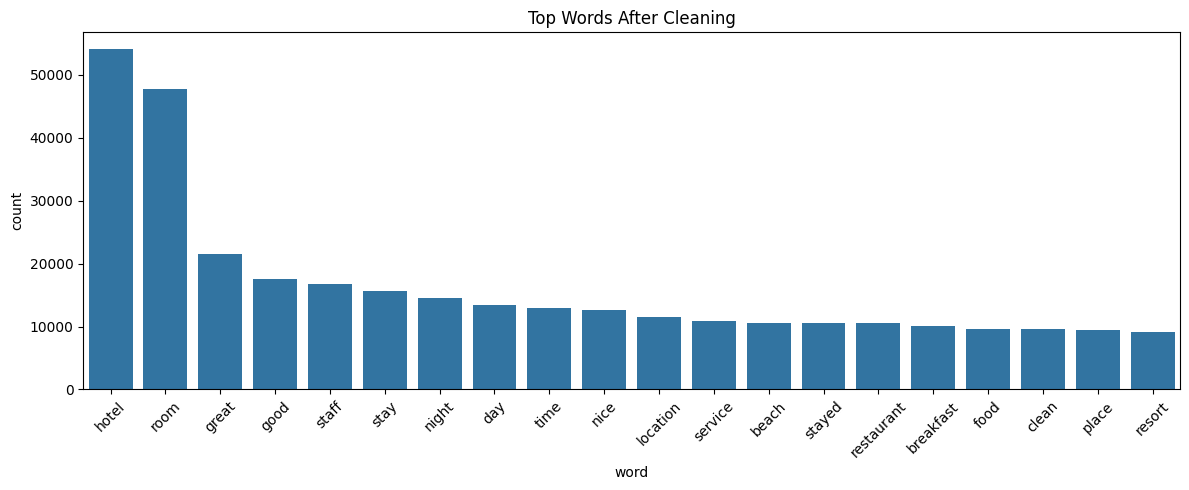

In [9]:
# Show frequent words to visualize cleaned dataset
from collections import Counter  # Counter for frequency stats
freq = Counter(' '.join(df['clean_text'].tolist()).split())  # Build token frequencies
top = pd.DataFrame(freq.most_common(20), columns=['word', 'count'])  # Top 20 words
display(top)  # Display table
plt.figure(figsize=(12, 5))  # Plot canvas
sns.barplot(data=top, x='word', y='count')  # Bar chart
plt.xticks(rotation=45)  # Rotate labels
plt.title('Top Words After Cleaning')  # Title
plt.tight_layout()  # Layout
plt.show()  # Render

In [10]:
# Tokenization + 80/20 split + percentile-based padding
X = df['clean_text'].values  # Text features
y = df['label'].values  # Labels
X_train_text, X_test_text, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)  # 80/20 split
VOCAB_SIZE = 20000  # Max vocab
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')  # Create tokenizer
tokenizer.fit_on_texts(X_train_text)  # Fit on train only
X_train_seq = tokenizer.texts_to_sequences(X_train_text)  # Train sequences
X_test_seq = tokenizer.texts_to_sequences(X_test_text)  # Test sequences
lens = np.array([len(s) for s in X_train_seq])  # Sequence lengths
MAX_LEN = int(np.percentile(lens, 95))  # 95th percentile length
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')  # Pad train
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')  # Pad test
print('MAX_LEN:', MAX_LEN, 'Train shape:', X_train_pad.shape, 'Test shape:', X_test_pad.shape)  # Shapes

MAX_LEN: 251 Train shape: (16392, 251) Test shape: (4099, 251)


In [11]:
# Build Model 1: Simple RNN + trainable embedding
def build_rnn(vocab_size, max_len, emb_dim=128):  # RNN builder
    m = Sequential(name='simple_rnn')  # Model
    m.add(Embedding(input_dim=vocab_size, output_dim=emb_dim, input_length=max_len))  # Embedding layer
    m.add(SimpleRNN(64))  # Recurrent layer
    m.add(Dropout(0.3))  # Dropout
    m.add(Dense(32, activation='relu'))  # Dense hidden
    m.add(Dense(1, activation='sigmoid'))  # Binary output
    return m  # Return model
model_rnn = build_rnn(VOCAB_SIZE, MAX_LEN)  # Instantiate model
model_rnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])  # Compile model
model_rnn.summary()  # Summary

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "simple_rnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Build Model 2: LSTM + trainable embedding
def build_lstm(vocab_size, max_len, emb_dim=128):  # LSTM builder
    m = Sequential(name='lstm_trainable')  # Model
    m.add(Embedding(input_dim=vocab_size, output_dim=emb_dim, input_length=max_len))  # Embedding layer
    m.add(Bidirectional(LSTM(64)))  # BiLSTM layer
    m.add(Dropout(0.3))  # Dropout
    m.add(Dense(32, activation='relu'))  # Dense hidden
    m.add(Dense(1, activation='sigmoid'))  # Binary output
    return m  # Return model
model_lstm = build_lstm(VOCAB_SIZE, MAX_LEN)  # Instantiate model
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])  # Compile model
model_lstm.summary()  # Summary

Model: "lstm_trainable"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Build Model 3: LSTM + pretrained embeddings (GloVe vectors via gensim)
import gensim.downloader as api  # Gensim downloader
w2v = api.load('glove-wiki-gigaword-50')  # Load 50d pretrained vectors
EMB_DIM = w2v.vector_size  # Embedding dimension
word_index = tokenizer.word_index  # Tokenizer index
num_words = min(VOCAB_SIZE, len(word_index) + 1)  # Effective vocab size
emb_matrix = np.zeros((num_words, EMB_DIM))  # Init embedding matrix
for w, i in word_index.items():
    if i < num_words and w in w2v:
        emb_matrix[i] = w2v[w]  # Fill vector from pretrained model
def build_lstm_pretrained(max_len, num_words, emb_dim, matrix):  # Model 3 builder
    m = Sequential(name='lstm_pretrained')  # Model
    m.add(Embedding(input_dim=num_words, output_dim=emb_dim, weights=[matrix], input_length=max_len, trainable=False))  # Frozen embedding
    m.add(Bidirectional(LSTM(64)))  # BiLSTM layer
    m.add(Dropout(0.3))  # Dropout
    m.add(Dense(32, activation='relu'))  # Dense hidden
    m.add(Dense(1, activation='sigmoid'))  # Binary output
    return m  # Return model
model_lstm_pre = build_lstm_pretrained(MAX_LEN, num_words, EMB_DIM, emb_matrix)  # Instantiate model
model_lstm_pre.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])  # Compile model
model_lstm_pre.summary()  # Summary

Model: "lstm_pretrained"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

In [14]:
# Train all models with early stopping
cb = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),  # Prevent overfit
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),  # LR reduction
]  # Callback list
def train_one(model, x, y, name, epochs=10, batch_size=64):  # Training helper
    t0 = time.time()  # Start timer
    h = model.fit(x, y, validation_split=0.2, epochs=epochs, batch_size=batch_size, callbacks=cb, verbose=1)  # Fit model
    sec = time.time() - t0  # Elapsed time
    print(name, 'seconds:', round(sec, 2))  # Print timing
    return h, sec  # Return history and time
h_rnn, t_rnn = train_one(model_rnn, X_train_pad, y_train, 'Simple RNN')  # Train model 1
h_lstm, t_lstm = train_one(model_lstm, X_train_pad, y_train, 'LSTM Trainable')  # Train model 2
h_pre, t_pre = train_one(model_lstm_pre, X_train_pad, y_train, 'LSTM Pretrained')  # Train model 3

Epoch 1/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.7357 - loss: 0.5822 - val_accuracy: 0.7341 - val_loss: 0.5791 - learning_rate: 0.0010
Epoch 2/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.7416 - loss: 0.5721 - val_accuracy: 0.7328 - val_loss: 0.5813 - learning_rate: 0.0010
Epoch 3/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - accuracy: 0.7473 - loss: 0.5645 - val_accuracy: 0.7264 - val_loss: 0.5879 - learning_rate: 0.0010
Epoch 4/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 12s 58ms/step - accuracy: 0.7560 - loss: 0.5460 - val_accuracy: 0.7255 - val_loss: 0.5957 - learning_rate: 5.0000e-04
Simple RNN seconds: 46.1
Epoch 1/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 46s 198ms/step - accuracy: 0.8476 - loss: 0.3521 - val_accuracy: 0.8914 - val_loss: 0.2663 - learning_rate: 0.0010
Epoch 2/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 39s 192ms/step - accuracy: 0.9311 - loss: 0.1833 - val_accuracy: 0.8893 - val_loss: 0.3314 - learning_rate: 0.0010
Epoch 3/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 35s 1


Simple RNN accuracy: 0.7365
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1080
           1     0.7365    1.0000    0.8483      3019

    accuracy                         0.7365      4099
   macro avg     0.3683    0.5000    0.4241      4099
weighted avg     0.5425    0.7365    0.6248      4099



C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

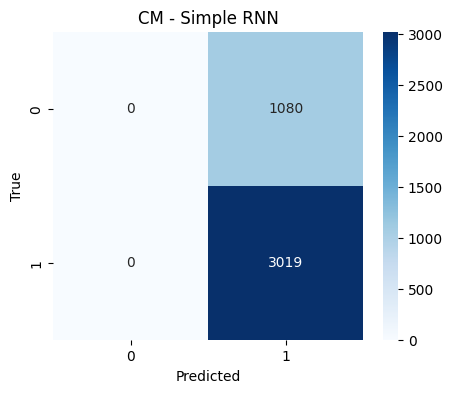


LSTM Trainable accuracy: 0.8773
              precision    recall  f1-score   support

           0     0.7511    0.7991    0.7743      1080
           1     0.9264    0.9053    0.9157      3019

    accuracy                         0.8773      4099
   macro avg     0.8388    0.8522    0.8450      4099
weighted avg     0.8802    0.8773    0.8785      4099



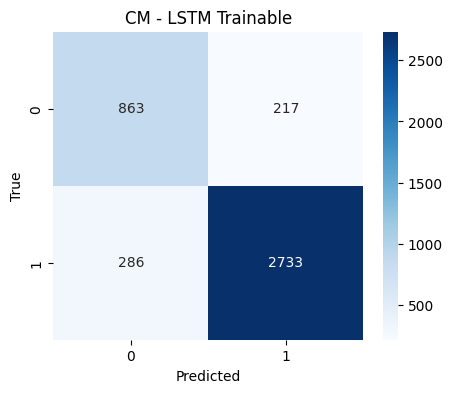


LSTM Pretrained accuracy: 0.8502
              precision    recall  f1-score   support

           0     0.7453    0.6556    0.6975      1080
           1     0.8819    0.9198    0.9005      3019

    accuracy                         0.8502      4099
   macro avg     0.8136    0.7877    0.7990      4099
weighted avg     0.8459    0.8502    0.8470      4099



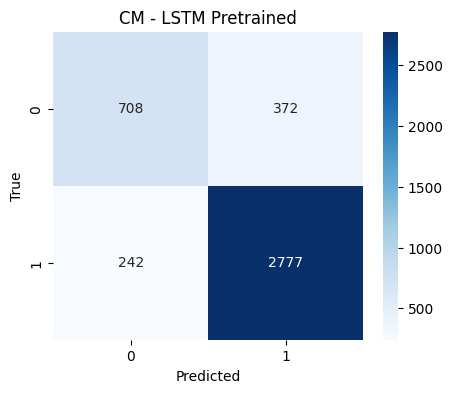

In [15]:
# Evaluate models with accuracy, confusion matrix, and report
def eval_bin(model, x_test, y_test, name):  # Eval helper
    prob = model.predict(x_test, verbose=0).ravel()  # Probabilities
    pred = (prob >= 0.5).astype(int)  # Binary predictions
    acc = accuracy_score(y_test, pred)  # Accuracy
    print('\n' + name + ' accuracy:', round(acc, 4))  # Print accuracy
    print(classification_report(y_test, pred, digits=4))  # Class report
    cm = confusion_matrix(y_test, pred)  # Confusion matrix
    plt.figure(figsize=(5, 4))  # Figure
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')  # Matrix heatmap
    plt.title('CM - ' + name)  # Title
    plt.xlabel('Predicted')  # X label
    plt.ylabel('True')  # Y label
    plt.show()  # Render
    return acc, pred  # Return accuracy and predictions
acc_rnn, pred_rnn = eval_bin(model_rnn, X_test_pad, y_test, 'Simple RNN')  # Eval model 1
acc_lstm, pred_lstm = eval_bin(model_lstm, X_test_pad, y_test, 'LSTM Trainable')  # Eval model 2
acc_pre, pred_pre = eval_bin(model_lstm_pre, X_test_pad, y_test, 'LSTM Pretrained')  # Eval model 3

In [16]:
# Error analysis and comparison table
cmp = pd.DataFrame([
    {'model': 'Simple RNN', 'accuracy': acc_rnn, 'train_time_sec': t_rnn},
    {'model': 'LSTM Trainable', 'accuracy': acc_lstm, 'train_time_sec': t_lstm},
    {'model': 'LSTM Pretrained', 'accuracy': acc_pre, 'train_time_sec': t_pre},
])  # Create comparison table
display(cmp.sort_values('accuracy', ascending=False))  # Show sorted results
best = cmp.sort_values('accuracy', ascending=False).iloc[0]['model']  # Identify best model
pred_best = pred_rnn if best == 'Simple RNN' else (pred_lstm if best == 'LSTM Trainable' else pred_pre)  # Choose best prediction set
mis_idx = np.where(pred_best != y_test)[0]  # Misclassified indices
print('Misclassified count:', len(mis_idx))  # Print error count
for i in mis_idx[:3]:
    print('\nSample:', i)  # Sample index
    print('Text:', X_test_text[i][:350])  # Show text snippet
    print('True:', y_test[i], 'Pred:', pred_best[i])  # Show true vs predicted
cmp.to_csv('part3_metrics_summary.csv', index=False)  # Save comparison

,model,accuracy,train_time_sec
1,LSTM Trainable,0.877287,162.917489
2,LSTM Pretrained,0.850207,79.280872
0,Simple RNN,0.736521,46.103286


Misclassified count: 503

Sample: 2
Text: worth agree review posted radisson solid choice stayed radisson waikiki prince kuhio week september floor ocean view room great scene morning evening hotel short walk shop restaurant area street outside little bit noisy nothing like main street run hotel directly beach problem elevator use service elevator near elevator use pool ocean minute walk a
True: 1 Pred: 0

Sample: 5
Text: great price location orlando familiar vacation went miami day music concert american airline arena pro price location excellent especially hotel great location close airport really look like new room clean nice basic hotel want stay lot time room perfect arrive sleep free breakfast con findin opinion hard good price clean hotel miami form good opin
True: 1 Pred: 0

Sample: 7
Text: pleasant basic hotel stay absolutely fine room pleasant clean breakfast buffet typical waffle egg cereal fruit employee nice shuttle definite plus convenient trip major area surprisingly qui

In [17]:
# Optional GUI (extra challenge) with Gradio
import gradio as gr  # Uncomment after installing gradio
def predict_sentiment(text):  # Prediction function
    clean = clean_text(text)  # Apply same cleaning
    seq = tokenizer.texts_to_sequences([clean])  # Tokenize input
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')  # Pad input
    prob = float(model_lstm_pre.predict(pad, verbose=0).ravel()[0])  # Use pretrained model by default
    pred_class = int(prob >= 0.5)  # 1=positive, 0=negative based on training labels
    sentiment = 'Positive' if pred_class == 1 else 'Negative'

    # Debug logs for quick validation during UI testing
    print(f"[DEBUG] raw_input={text!r}")
    print(f"[DEBUG] clean_text={clean!r}")
    print(f"[DEBUG] tokens={len(seq[0])}, nonzero_padded={int((pad[0] != 0).sum())}")
    print(f"[DEBUG] prob_positive_class1={prob:.6f}, threshold=0.5, pred_class={pred_class}, sentiment={sentiment}")

    return {
        'sentiment': sentiment,
        'pred_class': pred_class,
        'prob_positive_class1': prob,
        'threshold': 0.5
    }  # Output label + score + debug-friendly fields
ui = gr.Interface(fn=predict_sentiment, inputs='text', outputs='json', title='Hotel Review Sentiment Predictor')  # Build UI
ui.launch()  # Launch UI



c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
